<a href="https://colab.research.google.com/github/ipek-yilmaz/-California-Housing-Data/blob/main/California_Housing_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("housing.csv")

In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


## Get the values of objects and apply encoding

In [ ]:
op_count = df["ocean_proximity"].value_counts()

In [ ]:
op_count

<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: ocean_proximity, dtype: int64

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


Text(0.5, 0, 'Ocean proximity')

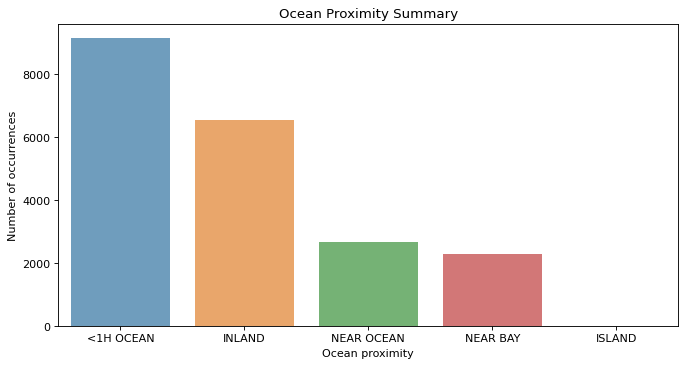

In [ ]:
plt.figure(figsize=(10,5), dpi=80)
sns.barplot(op_count.index, op_count.values, alpha=0.7)
plt.title("Ocean Proximity Summary")
plt.ylabel("Number of occurrences", fontsize=10)
plt.xlabel("Ocean proximity", fontsize=10)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["ocean_proximity"] = le.fit_transform(df["ocean_proximity"])

In [ ]:
df.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3


In [ ]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [ ]:
total_number_of_bedrooms = len(df["total_bedrooms"])

In [ ]:
total_number_of_bedrooms

20640

In [ ]:
#get the # of nan values for total bedrooms
nan_values_for_total_bedrooms = df["total_bedrooms"].isna().sum()

In [ ]:
nan_values_for_total_bedrooms

207

In [ ]:
print("Percentage of nan total_bedrooms over whole set", ((
    nan_values_for_total_bedrooms/total_number_of_bedrooms)*100))

Percentage of nan total_bedrooms over whole set 1.002906976744186


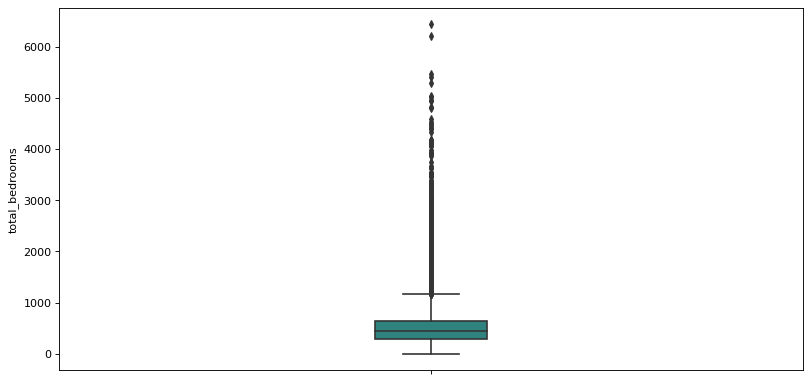

In [ ]:
plt.figure(figsize=(12,6), dpi=80)
sns.boxplot(y=df["total_bedrooms"], palette="viridis", width=0.15)

In [ ]:
#If it necessary apply IQR

In [ ]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(0)

In [ ]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

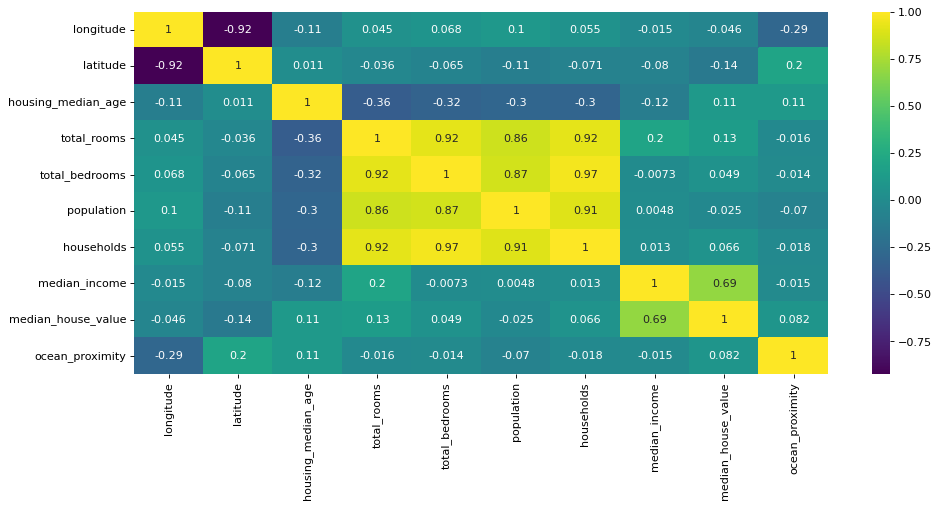

In [ ]:
plt.figure(figsize=(14,6), dpi=80)
sns.heatmap(data=df.corr(), cmap="viridis", annot=True)

In [ ]:
df.drop(["total_rooms", "households"], axis=1, inplace=True)

## Visualize as hist

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f02881e4350>,
      dtype=object)

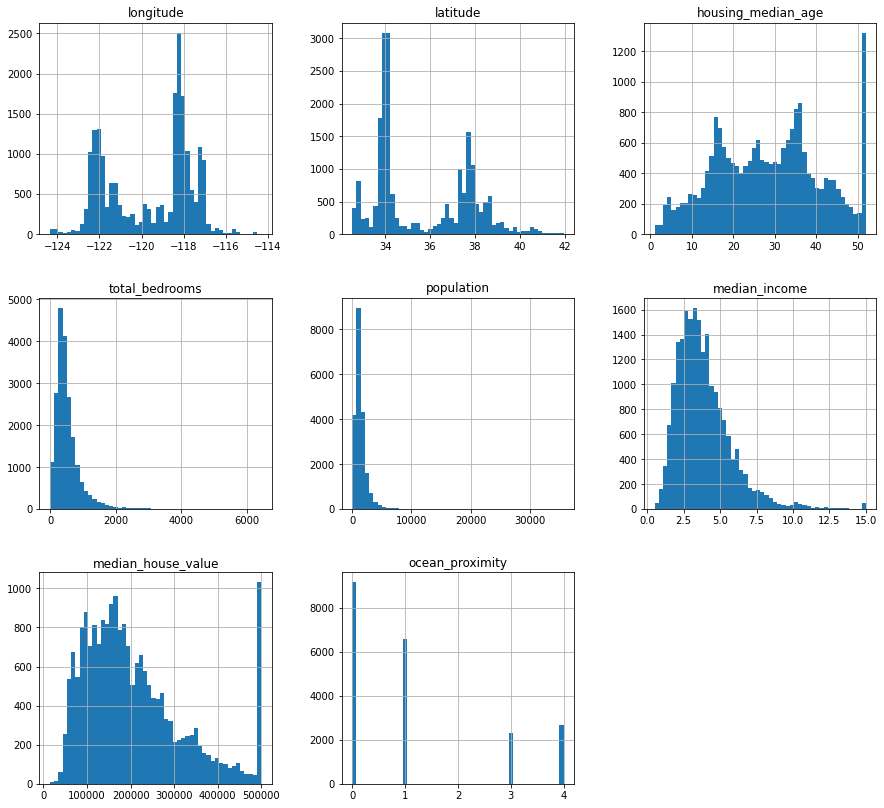

In [ ]:
df.hist(bins=50, figsize=(15,14))

Given that .botplot() and .hist() only handle numerical features. We cannot forget ocean_proximity, which is object type (no need to change to string)

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f0278610e10>,
      dtype=object)

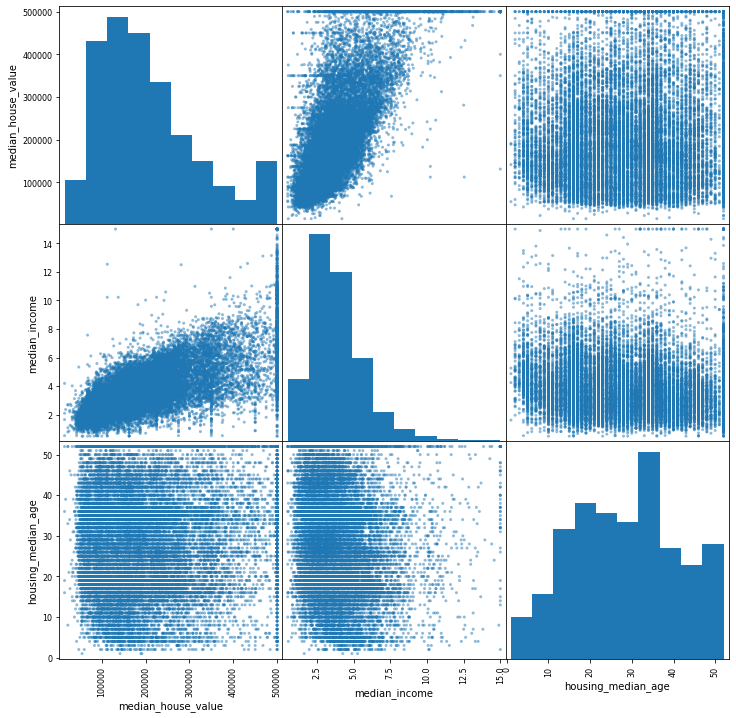

In [ ]:
attributes = ['median_house_value', 'median_income', 'housing_median_age']
pd.plotting.scatter_matrix(df[attributes], figsize=(12,12))

Data Cleaning and Transformation
Typically, data need to be cleaned and transformed before trying different ML algorithms.

missing data in one attribute.
Three ways to handle this:

remove the observations with missing values using dropna();



```
housing.dropna(subset=['total_bedrooms'])
```


remove the entire attribute using drop();



```
housing.drop('total_bedrooms', axis=1)
```


set/impute the missing values using fillna()


```
median = housing['total_bedroom'].median()
housing['total_bedrooms'].fillna(median, inplace=True)
```



# using Scikit-Learn Imputer


```
from sklearn.preprocessing import Imputer
imputer = Imputer(strategy='median')```
```
#### remove non-numerical attributes for Imputer by making a copy of the dataframe


```
housing_num = housing.drop('ocean_proximity', axis=1)
imputer.fit(housing_num)
x = imputer.transform(housing_num)  # this is a Numpy array
housing_tr = pd.DataFrame(x, columns=housing_num.columns)  # change a Numpy array to a DataFrame
housing_tr.info()  # no missing values

```

  # this computes median for each attributes and store the result in statistics_ variable
imputer.statistics_  # same result as housing_num.median().values

## Split train and tet set

In [ ]:
X = df.drop(["median_house_value"], axis=1)
y = df["median_house_value"]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
X_train

,longitude,latitude,housing_median_age,total_bedrooms,population,median_income,ocean_proximity
7061,-118.02,33.93,35.0,398.0,1218.0,4.1312,0
14689,-117.09,32.79,20.0,534.0,999.0,2.8631,4
17323,-120.14,34.59,24.0,282.0,731.0,4.2026,4
10056,-121.00,39.26,14.0,151.0,302.0,3.1094,1
15750,-122.45,37.77,52.0,708.0,1526.0,3.3068,3
...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,201.0,658.0,6.3700,0
11964,-117.43,34.02,33.0,570.0,1753.0,3.0500,1
5390,-118.38,34.03,36.0,569.0,1756.0,2.9344,0
860,-121.96,37.58,15.0,597.0,1777.0,5.7192,0


In [ ]:
y_train

7061     193800.0
14689    169700.0
17323    259800.0
10056    136100.0
15750    500001.0
           ...   
11284    229200.0
11964     97800.0
5390     222100.0
860      283500.0
15795    325000.0
Name: median_house_value, Length: 14448, dtype: float64

## Feature Scaling

In [ ]:
from sklearn.svm import LinearSVR
svm_reg = LinearSVR(epsilon=1.5)
svm_reg.fit(X_train, y_train)

/usr/local/lib/python3.7/dist-packages/sklearn/svm/_base.py:947: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  "the number of iterations.", ConvergenceWarning)


LinearSVR(C=1.0, dual=True, epsilon=1.5, fit_intercept=True,
          intercept_scaling=1.0, loss='epsilon_insensitive', max_iter=1000,
          random_state=None, tol=0.0001, verbose=0)

In [ ]:
y_pred = svm_reg.predict(X_test)

## RMSE

In [ ]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print(np.sqrt(mse))

98423.37510118476


In [ ]:
score = svm_reg.score(X_test, y_test)
print("Accuracty for SVR is : ", score)

Accuracty for SVR is :  0.26195316176332095


###This model was created only to show the basic steps for data science beginners. It is left to the reader to examine the codes and why the model used gives low results and which model should be used. This is your challenge. Have fun 😄